In [10]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
#Only get Data Analyst in a specific location
#df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

#Drops NA values from the column for plotting
#df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

#df_DA_US['salary_year_avg'].sample(10)

<Axes: >

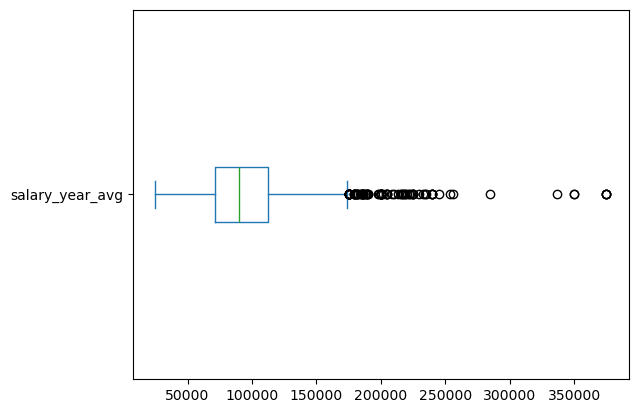

In [ ]:
#Pandas
#df_DA_US['salary_year_avg'].plot(kind='box', vert=False)

#Matplotlib
#plt.boxplot(df_DA_US['salary_year_avg'], vert=False)

C:\Users\polak\AppData\Local\Temp\ipykernel_24072\2789515064.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list, labels=job_titles, vert=False)


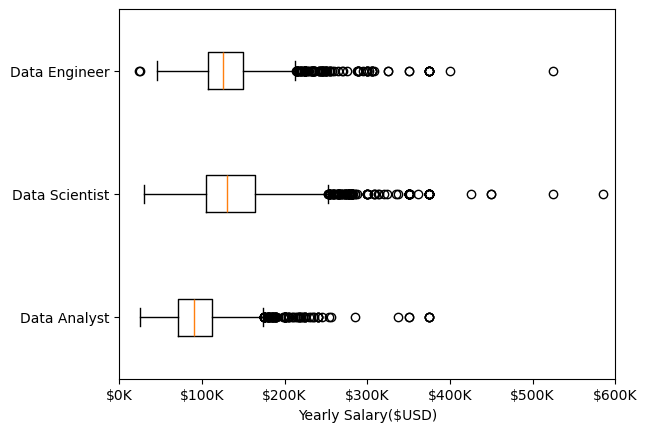

In [25]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

#Filter to get appropiate job titles
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

#Job Listing
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

#Matplotlib
plt.boxplot(job_list, labels=job_titles, vert=False)
plt.xlabel('Yearly Salary($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.show() #Removes "MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9;"